# Lab 1 — Inherently Interpretable Models
### M.Tech Course: Explainable & Interpretable Machine Learning

**Lab Title:** Inherently Interpretable Models

**Duration:** 3 hours

---

## 1. Introduction

Machine learning models are broadly classified into two categories based on how easily
a human can understand *why* they make a particular prediction:

| Category | Description | Examples |
|---|---|---|
| **Black-box models** | Predictions are accurate, but the internal decision logic is too complex for a human to follow directly. Explanations require *post-hoc* tools (LIME, SHAP, etc.). | Random Forests, Gradient Boosting, Deep Neural Networks |
| **Inherently (intrinsically) interpretable models** | The model's structure *itself* is simple enough that a human can read off the reasoning — no separate explanation technique is needed. | Linear/Logistic Regression, Decision Trees, Decision Rules, k-NN, Naive Bayes, Generalized Additive Models (GAMs) |

This lab focuses on the **second** category. We will train several inherently
interpretable models on a real dataset, and for each one we will explicitly answer:

1. **What does the model look like internally?** (its parameters / structure)
2. **How do we read that structure as an explanation?**
3. **What are the interpretability properties** (simulatability, decomposability, sparsity) it satisfies?
4. **What is the accuracy–interpretability trade-off** compared to the others?

### Properties used to judge interpretability (Lipton, 2016)
- **Simulatability** — Can a human mentally "run" the model on an input in a reasonable amount of time?
- **Decomposability** — Can each part of the model (a coefficient, a tree node, a rule) be given an intuitive explanation on its own?
- **Algorithmic transparency** — Do we understand *how* the training procedure arrives at the model?

---

## 2. Learning Objectives

By the end of this lab, students will be able to:

1. Train and interpret a **Logistic Regression** model using coefficients and odds ratios.
2. Train and interpret a **Decision Tree** by reading tree paths as IF–THEN rules.
3. Extract an explicit **rule list** from a tree and evaluate its size/complexity.
4. Interpret a **k-Nearest Neighbors** model using case-based (example-based) reasoning.
5. Interpret a **Naive Bayes** model via per-feature log-likelihood contributions.
6. Train a **Generalized Additive Model (GAM)** and read its per-feature shape functions.
7. Quantitatively compare **accuracy vs. interpretability** across all models.


## 3. Environment Setup

We use only well-known Python libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, and `pygam` (for the Generalized Additive Model experiment).

> If `pygam` is not installed in your environment, run:
> ```
> pip install pygam
> ```


In [2]:
pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pygam import LogisticGAM, s

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 4. Dataset: Breast Cancer Wisconsin (Diagnostic)

We use the **Breast Cancer Wisconsin** dataset built into scikit-learn. It is a good
choice for an *interpretability* lab because:

- It is a **binary classification** task (malignant vs. benign) — easy to reason about.
- Its 30 features (e.g., `mean radius`, `mean texture`, `worst concavity`) have **real,
  human-understandable clinical meaning**, so coefficients and rules can be interpreted
  in domain terms rather than abstract numbers.
- It is small enough to visualize trees and rules without clutter.

For readability in this lab, we will work with a **reduced subset of 6 features**.


In [4]:
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

# Pick 6 clinically-intuitive features to keep the models easy to read
selected_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean smoothness", "mean concavity", "worst area"
]
X = X_full[selected_features]

print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts().rename({0: "malignant", 1: "benign"}))
X.head()


Dataset shape: (569, 6)
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area
0,17.99,10.38,122.80,0.11840,0.3001,2019.0
1,20.57,17.77,132.90,0.08474,0.0869,1956.0
2,19.69,21.25,130.00,0.10960,0.1974,1709.0
3,11.42,20.38,77.58,0.14250,0.2414,567.7
4,20.29,14.34,135.10,0.10030,0.1980,1575.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize features -- important for reading logistic-regression coefficients
# on a comparable scale, and for k-NN distance calculations.
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 426  Test size: 143


In [19]:
# Exercise 1: Use all 30 original features

X_30 = X_full.copy()

X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_30,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler_30 = StandardScaler()

X_train_30_s = pd.DataFrame(
    scaler_30.fit_transform(X_train_30),
    columns=X_30.columns,
    index=X_train_30.index
)

X_test_30_s = pd.DataFrame(
    scaler_30.transform(X_test_30),
    columns=X_30.columns,
    index=X_test_30.index
)

print("All-feature dataset shape:", X_30.shape)
print("Training set:", X_train_30.shape)
print("Test set:", X_test_30.shape)

All-feature dataset shape: (569, 30)
Training set: (426, 30)
Test set: (143, 30)


## 5. Experiment 1 — Logistic Regression

**Why it is inherently interpretable:** The model computes a single linear combination
of the (standardized) features, then squashes it through a sigmoid:

$$P(\text{benign}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)$$

Each coefficient $\beta_i$ tells us, on its own (decomposability), how that feature
pushes the prediction toward "benign" or "malignant" — holding the other features fixed.
Exponentiating a coefficient, $e^{\beta_i}$, gives the **odds ratio**: how much the odds
of "benign" multiply for a one-standard-deviation increase in that feature.


In [20]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)

y_pred_lr = logreg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}\n")

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_table.to_string(index=False))


Logistic Regression Test Accuracy: 0.9301

        feature  coefficient  odds_ratio
     worst area    -3.251220    0.038727
mean smoothness    -1.499294    0.223288
   mean texture    -1.336668    0.262720
 mean concavity    -1.022198    0.359803
    mean radius    -0.940079    0.390597
 mean perimeter    -0.858407    0.423837


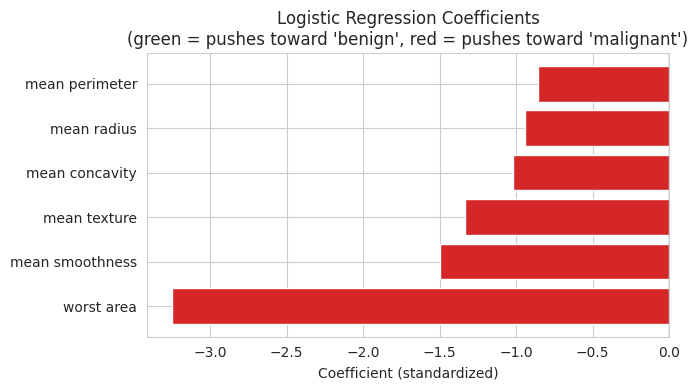

In [21]:
plt.figure(figsize=(7, 4))
colors = ["#d62728" if c < 0 else "#2ca02c" for c in coef_table["coefficient"]]
plt.barh(coef_table["feature"], coef_table["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Logistic Regression Coefficients\n(green = pushes toward 'benign', red = pushes toward 'malignant')")
plt.tight_layout()
plt.show()


In [33]:
# Exercise 1 - Experiment 1
# Logistic Regression using all 30 features

logreg_30 = LogisticRegression(max_iter=5000)

logreg_30.fit(X_train_30_s, y_train_30)

# Predictions
y_pred_lr_30 = logreg_30.predict(X_test_30_s)

# Accuracy
acc_lr_30 = accuracy_score(y_test_30, y_pred_lr_30)

print(f"Logistic Regression (30 features) Test Accuracy: {acc_lr_30:.4f}\n")

# Coefficients and odds ratios
coef_table_30 = pd.DataFrame({
    "feature": X_30.columns,
    "coefficient": logreg_30.coef_[0],
    "odds_ratio": np.exp(logreg_30.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_table_30.to_string(index=False))

Logistic Regression (30 features) Test Accuracy: 0.9860

                feature  coefficient  odds_ratio
          worst texture    -1.250149    0.286462
           radius error    -1.070102    0.342973
         worst symmetry    -0.957045    0.384026
   worst concave points    -0.941888    0.389891
             area error    -0.941059    0.390214
             worst area    -0.925812    0.396210
           worst radius    -0.917480    0.399525
        worst concavity    -0.796758    0.450788
        worst perimeter    -0.721168    0.486184
       mean compactness     0.694230    2.002167
    mean concave points    -0.676929    0.508175
       worst smoothness    -0.669648    0.511889
      compactness error     0.616426    1.852295
         mean concavity    -0.565443    0.568108
              mean area    -0.557334    0.572734
            mean radius    -0.523064    0.592702
           mean texture    -0.518670    0.595312
        perimeter error    -0.491072    0.611970
         mea

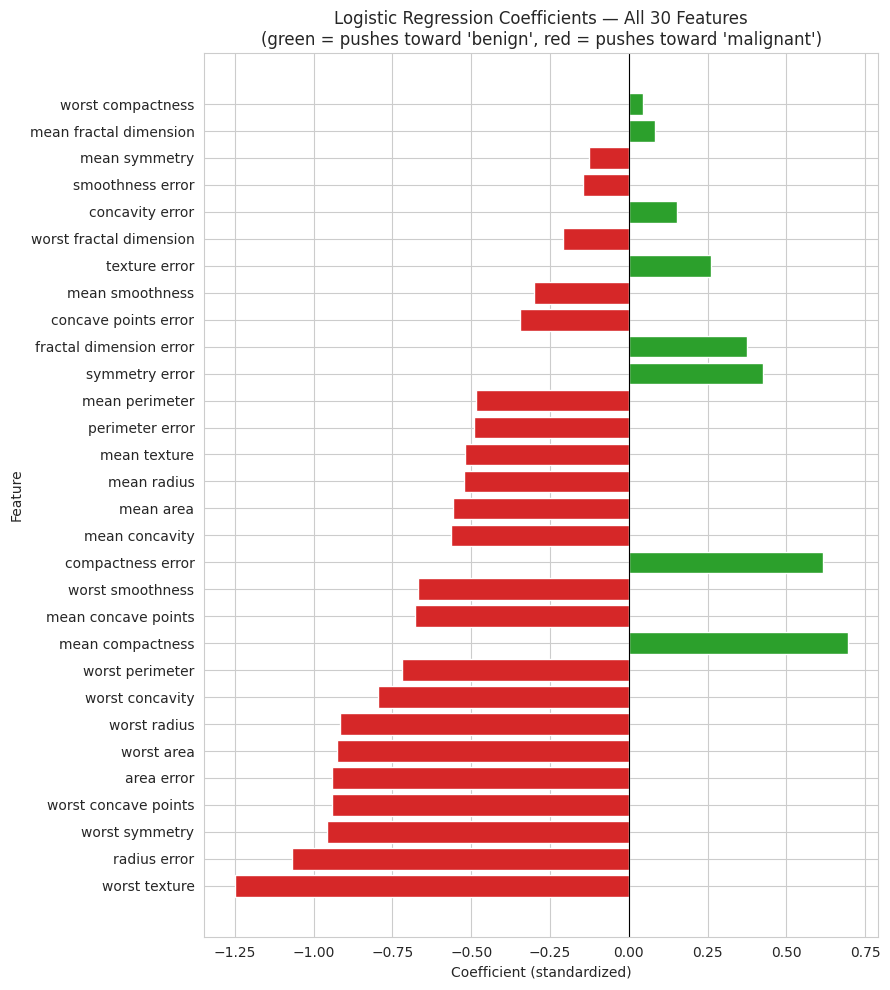

In [35]:
plt.figure(figsize=(9, 10))

colors = [
    "#d62728" if c < 0 else "#2ca02c"
    for c in coef_table_30["coefficient"]
]

plt.barh(
    coef_table_30["feature"],
    coef_table_30["coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Coefficient (standardized)")
plt.ylabel("Feature")

plt.title(
    "Logistic Regression Coefficients — All 30 Features\n"
    "(green = pushes toward 'benign', red = pushes toward 'malignant')"
)

plt.tight_layout()
plt.show()

**How to read this (worked example):**
Suppose `worst area` has coefficient $\beta = -2.1$. Since features are standardized,
this means: *for every one-standard-deviation increase in `worst area` (holding other
features fixed), the log-odds of the tumor being benign drop by 2.1*, i.e. the odds of
malignancy increase by a factor of $e^{2.1} \approx 8.2$. This is a **fully simulatable**
explanation — a student can compute it by hand for any patient.


## 6. Experiment 2 — Decision Tree

**Why it is inherently interpretable:** A shallow decision tree can be read top-to-bottom
as a sequence of IF–THEN questions. Each **root-to-leaf path** is, by itself, a complete,
human-readable explanation for that prediction (decomposability + simulatability).

We deliberately restrict `max_depth=3` — deeper trees become accurate but lose
interpretability (too many paths for a human to hold in memory at once).


In [22]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)  # trees don't need scaled features

y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree (depth=3) Test Accuracy: {acc_tree:.4f}")
print(f"Number of leaves (= number of distinct explanation rules): {tree.get_n_leaves()}")


Decision Tree (depth=3) Test Accuracy: 0.9510
Number of leaves (= number of distinct explanation rules): 7


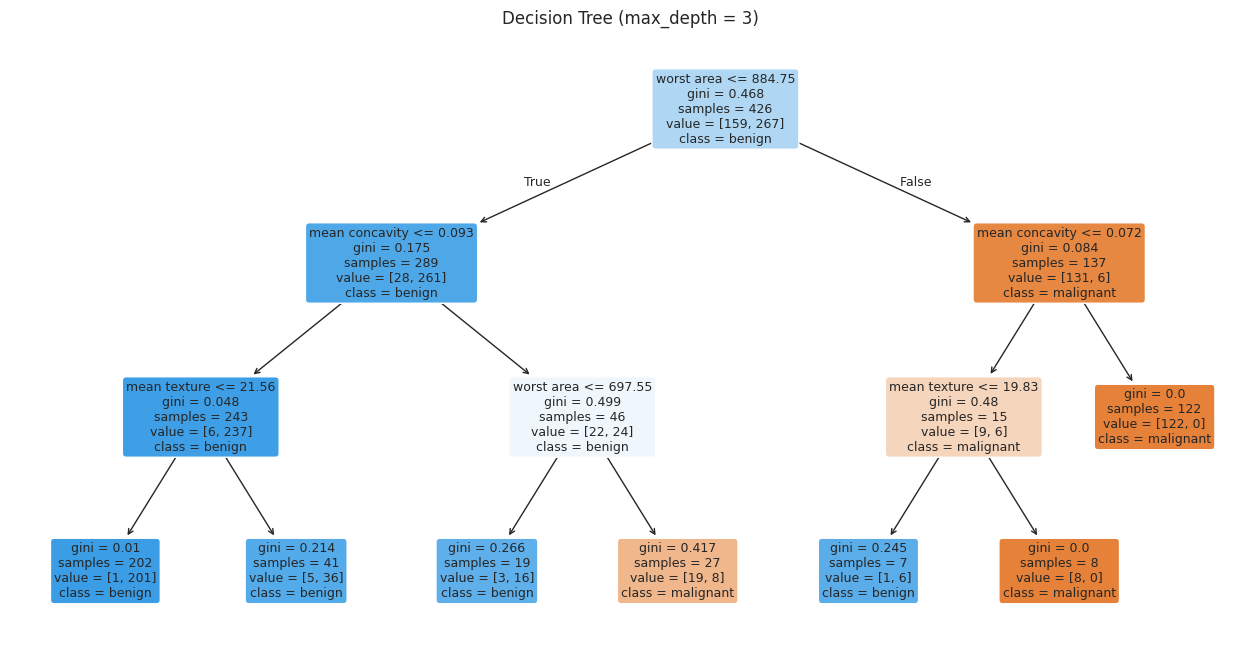

In [23]:
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth = 3)")
plt.show()


In [24]:
rules_text = export_text(tree, feature_names=list(X.columns))
print(rules_text)


|--- worst area <= 884.75
|   |--- mean concavity <= 0.09
|   |   |--- mean texture <= 21.56
|   |   |   |--- class: 1
|   |   |--- mean texture >  21.56
|   |   |   |--- class: 1
|   |--- mean concavity >  0.09
|   |   |--- worst area <= 697.55
|   |   |   |--- class: 1
|   |   |--- worst area >  697.55
|   |   |   |--- class: 0
|--- worst area >  884.75
|   |--- mean concavity <= 0.07
|   |   |--- mean texture <= 19.83
|   |   |   |--- class: 1
|   |   |--- mean texture >  19.83
|   |   |   |--- class: 0
|   |--- mean concavity >  0.07
|   |   |--- class: 0



In [36]:
# Exercise 1 - Experiment 2
# Decision Tree using all 30 features

tree_30 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_30.fit(X_train_30, y_train_30)

y_pred_tree_30 = tree_30.predict(X_test_30)

acc_tree_30 = accuracy_score(y_test_30, y_pred_tree_30)

print(f"Decision Tree (30 features, depth=3) Test Accuracy: {acc_tree_30:.4f}")
print(f"Number of leaves: {tree_30.get_n_leaves()}")

Decision Tree (30 features, depth=3) Test Accuracy: 0.9441
Number of leaves: 7


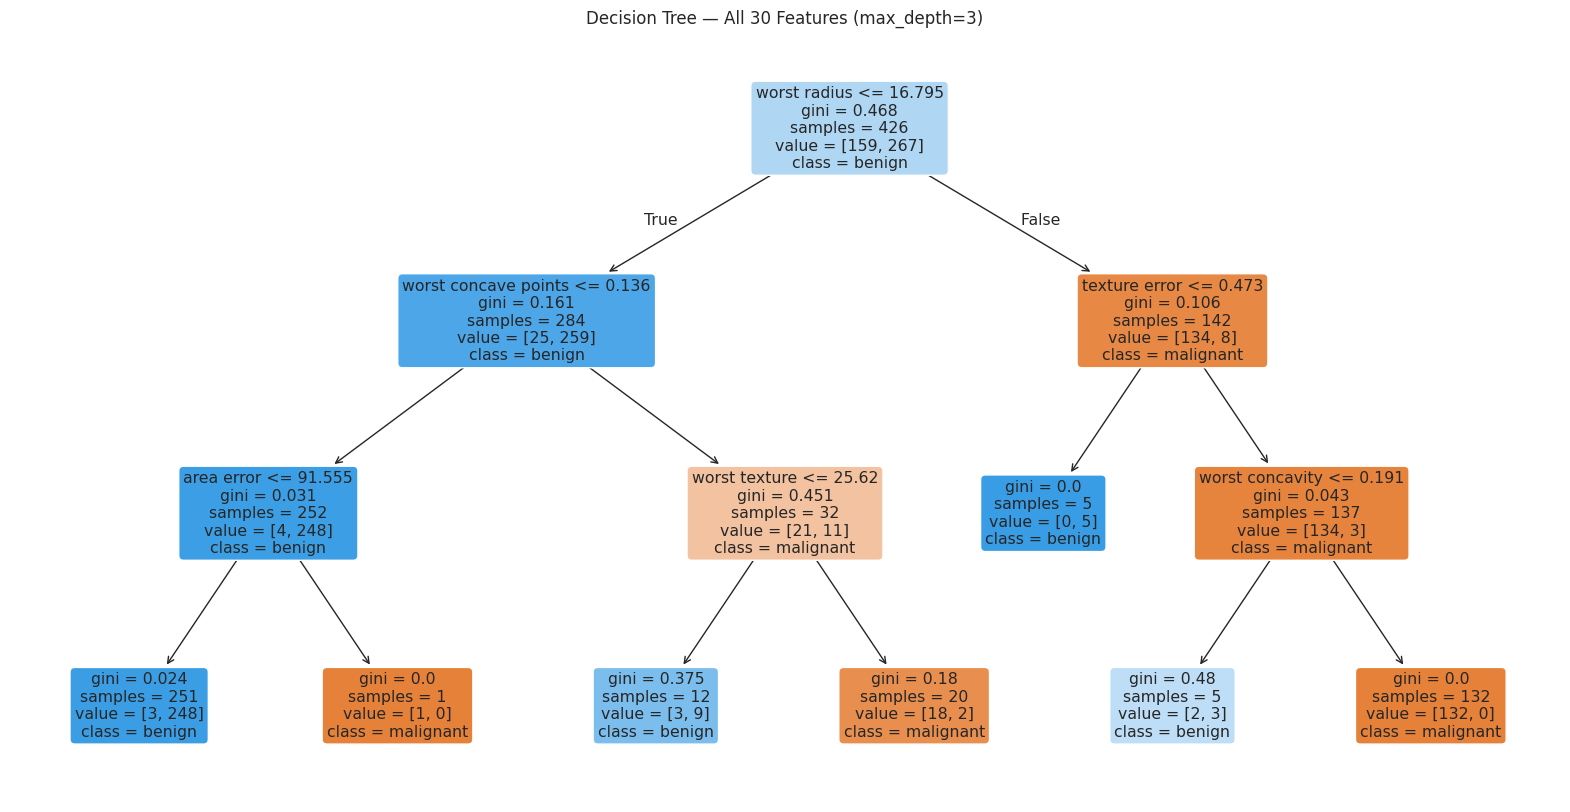

In [37]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_30,
    feature_names=X_30.columns,
    class_names=["malignant", "benign"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree — All 30 Features (max_depth=3)")
plt.show()

In [38]:
rules_30 = export_text(
    tree_30,
    feature_names=list(X_30.columns)
)

print(rules_30)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



**How to read this:** Each branch of the printed tree is literally an IF–THEN rule,
e.g. *"IF `worst area` <= 880.4 AND `mean concavity` <= 0.09 THEN predict benign."*
A clinician could apply this rule with a ruler and a calculator — no black box involved.


## 7. Experiment 3 — Explicit Rule List (Rule Extraction)

Beyond reading the tree diagram, we can **programmatically extract every root-to-leaf
path as an explicit IF–THEN rule string**. This is useful when we want to hand the
explanation to a non-technical stakeholder as a checklist, or count how many total
rules the model uses (a measure of model complexity / interpretability cost).


In [25]:
def extract_rules(tree_model, feature_names, class_names):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [f"({name} <= {threshold:.2f})"])
            recurse(tree_.children_right[node], conditions + [f"({name} > {threshold:.2f})"])
        else:
            counts = tree_.value[node][0]
            predicted_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()
            rule = "IF " + " AND ".join(conditions) if conditions else "TRUE"
            rules.append(f"{rule}  =>  predict '{predicted_class}'  (confidence={confidence:.2f}, n={int(counts.sum())})")

    recurse(0, [])
    return rules

rule_list = extract_rules(tree, list(X.columns), ["malignant", "benign"])
for i, r in enumerate(rule_list, 1):
    print(f"Rule {i}: {r}")

print(f"\nTotal number of rules extracted: {len(rule_list)}")


Rule 1: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture <= 21.56)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 2: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture > 21.56)  =>  predict 'benign'  (confidence=0.88, n=1)
Rule 3: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area <= 697.55)  =>  predict 'benign'  (confidence=0.84, n=1)
Rule 4: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area > 697.55)  =>  predict 'malignant'  (confidence=0.70, n=1)
Rule 5: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture <= 19.83)  =>  predict 'benign'  (confidence=0.86, n=1)
Rule 6: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture > 19.83)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 7: IF (worst area > 884.75) AND (mean concavity > 0.07)  =>  predict 'malignant'  (confidence=1.00, n=1)

Total number of rules extracted: 7


In [39]:
# Exercise 1 - Experiment 3
# Extract explicit rules from the 30-feature Decision Tree

def extract_rules_30(tree_model, feature_names, class_names):
    tree_ = tree_model.tree_

    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]

            recurse(
                tree_.children_left[node],
                conditions + [f"({name} <= {threshold:.2f})"]
            )

            recurse(
                tree_.children_right[node],
                conditions + [f"({name} > {threshold:.2f})"]
            )

        else:
            counts = tree_.value[node][0]

            predicted_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()

            rule = (
                "IF " + " AND ".join(conditions)
                if conditions
                else "TRUE"
            )

            rules.append(
                f"{rule} => predict '{predicted_class}' "
                f"(confidence={confidence:.2f}, n={int(counts.sum())})"
            )

    recurse(0, [])

    return rules


rule_list_30 = extract_rules_30(
    tree_30,
    list(X_30.columns),
    ["malignant", "benign"]
)

for i, r in enumerate(rule_list_30, 1):
    print(f"Rule {i}: {r}")

print(f"\nTotal number of rules extracted: {len(rule_list_30)}")

Rule 1: IF (worst radius <= 16.80) AND (worst concave points <= 0.14) AND (area error <= 91.56) => predict 'benign' (confidence=0.99, n=1)
Rule 2: IF (worst radius <= 16.80) AND (worst concave points <= 0.14) AND (area error > 91.56) => predict 'malignant' (confidence=1.00, n=1)
Rule 3: IF (worst radius <= 16.80) AND (worst concave points > 0.14) AND (worst texture <= 25.62) => predict 'benign' (confidence=0.75, n=1)
Rule 4: IF (worst radius <= 16.80) AND (worst concave points > 0.14) AND (worst texture > 25.62) => predict 'malignant' (confidence=0.90, n=1)
Rule 5: IF (worst radius > 16.80) AND (texture error <= 0.47) => predict 'benign' (confidence=1.00, n=1)
Rule 6: IF (worst radius > 16.80) AND (texture error > 0.47) AND (worst concavity <= 0.19) => predict 'benign' (confidence=0.60, n=1)
Rule 7: IF (worst radius > 16.80) AND (texture error > 0.47) AND (worst concavity > 0.19) => predict 'malignant' (confidence=1.00, n=1)

Total number of rules extracted: 7


In [40]:
# Average number of conditions per rule

condition_counts = []

for rule in rule_list_30:
    if rule.startswith("TRUE"):
        condition_counts.append(0)
    else:
        condition_part = rule.split("=>")[0]
        condition_counts.append(condition_part.count(" AND ") + 1)

avg_conditions_30 = np.mean(condition_counts)

print(f"Total rules: {len(rule_list_30)}")
print(f"Average conditions per rule: {avg_conditions_30:.2f}")

Total rules: 7
Average conditions per rule: 2.86


**Interpretability metric:** the **number of rules** and the **average number of
conditions per rule** are common, simple complexity measures for rule-based models.
Fewer, shorter rules are considered more interpretable (higher simulatability).


## 8. Experiment 4 — k-Nearest Neighbors (Case-Based / Example-Based Interpretability)

**Why it is inherently interpretable:** k-NN makes no explicit "model" at all — it
predicts a new point's label by looking at the $k$ most similar *training examples* and
taking a majority vote. The explanation for any prediction is simply: **"here are the
$k$ patients most similar to this one, and this is how they were diagnosed."** This is
called **case-based** or **example-based** interpretability — it mirrors how doctors
often reason ("this looks like Patient X, who turned out benign").


In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN (k=5) Test Accuracy: {acc_knn:.4f}")


k-NN (k=5) Test Accuracy: 0.9371


In [27]:
# Explain ONE specific test-set prediction using its nearest neighbors
sample_idx = 0
sample = X_test_s.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = knn.predict(sample)[0]

distances, neighbor_idx = knn.kneighbors(sample, n_neighbors=5)
neighbor_labels = y_train.iloc[neighbor_idx[0]].values

print(f"Test patient #{sample_idx}: true label = {true_label}, predicted = {pred_label}")
print(f"Labels of its 5 nearest training neighbors: {neighbor_labels}")
print("Explanation: the prediction is the majority vote among these 5 most similar patients.")

neighbor_table = X_train.iloc[neighbor_idx[0]].copy()
neighbor_table["distance"] = distances[0]
neighbor_table["label"] = neighbor_labels
neighbor_table


Test patient #0: true label = 1, predicted = 1
Labels of its 5 nearest training neighbors: [1 1 1 1 1]
Explanation: the prediction is the majority vote among these 5 most similar patients.


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area,distance,label
502,12.54,16.32,81.25,0.1158,0.05928,552.0,0.394665,1
145,11.90,14.65,78.11,0.1152,0.03710,509.6,0.623240,1
530,11.75,17.56,75.89,0.1073,0.05282,552.3,0.626712,1
142,11.43,17.31,73.66,0.1092,0.02031,503.0,0.674937,1
383,12.39,17.48,80.64,0.1042,0.05892,600.5,0.706261,1


In [41]:
# Exercise 1 - Experiment 4
# k-NN using all 30 features

knn_30 = KNeighborsClassifier(n_neighbors=5)

knn_30.fit(X_train_30_s, y_train_30)

y_pred_knn_30 = knn_30.predict(X_test_30_s)

acc_knn_30 = accuracy_score(y_test_30, y_pred_knn_30)

print(f"k-NN (k=5, 30 features) Test Accuracy: {acc_knn_30:.4f}")

k-NN (k=5, 30 features) Test Accuracy: 0.9790


In [42]:
# Find the 5 nearest training examples for the first test patient

distances, indices = knn_30.kneighbors(
    X_test_30_s.iloc[[0]],
    n_neighbors=5
)

nearest_examples = pd.DataFrame({
    "distance": distances[0],
    "training_index": X_train_30.index[indices[0]],
    "diagnosis": y_train_30.iloc[indices[0]].values
})

print(nearest_examples)

   distance  training_index  diagnosis
0  1.976692             502          1
1  2.148792             249          1
2  2.193188             221          1
3  2.205316             422          1
4  2.234937             394          1


## 9. Experiment 5 — Gaussian Naive Bayes

**Why it is inherently interpretable:** Naive Bayes assumes features are conditionally
independent given the class, so the prediction decomposes into a **sum of independent,
per-feature log-likelihood contributions**:

$$\log P(y \mid x) \;\propto\; \log P(y) + \sum_{i=1}^{p} \log P(x_i \mid y)$$

Each term $\log P(x_i \mid y)$ can be inspected on its own — exactly the *decomposability*
property we want.


In [28]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)

y_pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naive Bayes Test Accuracy: {acc_nb:.4f}")

# Show the learned per-class, per-feature Gaussian parameters (mean, variance)
nb_params = pd.DataFrame(nb.theta_, columns=X.columns, index=["malignant", "benign"])
print("\nLearned per-class feature means (standardized units):")
print(nb_params.to_string())


Gaussian Naive Bayes Test Accuracy: 0.9301

Learned per-class feature means (standardized units):
           mean radius  mean texture  mean perimeter  mean smoothness  mean concavity  worst area
malignant     0.949431      0.528204        0.966140         0.511243        0.896919    0.952863
benign       -0.565392     -0.314548       -0.575342        -0.304448       -0.534120   -0.567435


In [43]:
# Exercise 1 - Experiment 5
# Naive Bayes using all 30 features

nb_30 = GaussianNB()

nb_30.fit(X_train_30_s, y_train_30)

y_pred_nb_30 = nb_30.predict(X_test_30_s)

acc_nb_30 = accuracy_score(y_test_30, y_pred_nb_30)

print(f"Naive Bayes (30 features) Test Accuracy: {acc_nb_30:.4f}")

Naive Bayes (30 features) Test Accuracy: 0.9371


In [45]:
# Exercise 1 - Experiment 5
# Learned per-class feature means

nb_params_30 = pd.DataFrame(
    nb_30.theta_,
    columns=X_30.columns,
    index=["malignant", "benign"]
)

print("Learned per-class feature means (standardized units):")
print(nb_params_30.to_string())

Learned per-class feature means (standardized units):
           mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension
malignant     0.949431      0.528204        0.966140   0.925456         0.511243          0.791618        0.896919             1.015759       0.458913               -0.012224      0.725475      -0.055160         0.707645    0.730877         -0.140083           0.364029         0.312046               0.53212        0.006182                 0.059596      1.003178       0.582319         1.011579    0.952863          0.54

In [46]:
# Feature-wise log-likelihood ratio

log_likelihood_ratio_30 = (
    nb_30.theta_[1] - nb_30.theta_[0]
)

nb_feature_table_30 = pd.DataFrame({
    "feature": X_30.columns,
    "log_likelihood_difference": log_likelihood_ratio_30
})

nb_feature_table_30 = nb_feature_table_30.sort_values(
    "log_likelihood_difference",
    key=np.abs,
    ascending=False
)

print(nb_feature_table_30.to_string(index=False))

                feature  log_likelihood_difference
   worst concave points                  -1.647227
    mean concave points                  -1.620649
        worst perimeter                  -1.613981
           worst radius                  -1.600576
         mean perimeter                  -1.541483
             worst area                  -1.520298
            mean radius                  -1.514823
              mean area                  -1.476571
         mean concavity                  -1.431039
        worst concavity                  -1.378529
       mean compactness                  -1.263032
      worst compactness                  -1.246626
             area error                  -1.166118
           radius error                  -1.157499
        perimeter error                  -1.129052
          worst texture                  -0.929093
         worst symmetry                  -0.894710
       worst smoothness                  -0.877512
   concave points error        

**How to read this:** for a given feature, compare its mean under the "malignant"
row vs. the "benign" row. A test patient whose feature value sits much closer to the
"malignant" mean than the "benign" mean contributes positive evidence for malignancy —
and this contribution can be computed and shown to a user feature-by-feature.


## 10. Experiment 6 — Generalized Additive Model (GAM)

**Why it is inherently interpretable:** A GAM generalizes linear/logistic regression by
allowing each feature to have its own **smooth, non-linear shape function** $f_i$, while
still keeping the features additively separate (no interactions):

$$\text{logit}(P(y=1\mid x)) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)$$

Because the effect of each feature is still isolated in its own $f_i$, we can **plot**
$f_i$ against $x_i$ and read off the exact (possibly non-linear) relationship — something
plain logistic regression cannot capture, but which is still fully decomposable and
visually simulatable.


In [29]:
gam = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5)
).fit(X_train_s.values, y_train.values)

y_pred_gam = (gam.predict_mu(X_test_s.values) > 0.5).astype(int)
acc_gam = accuracy_score(y_test, y_pred_gam)
print(f"GAM Test Accuracy: {acc_gam:.4f}")


GAM Test Accuracy: 0.9650


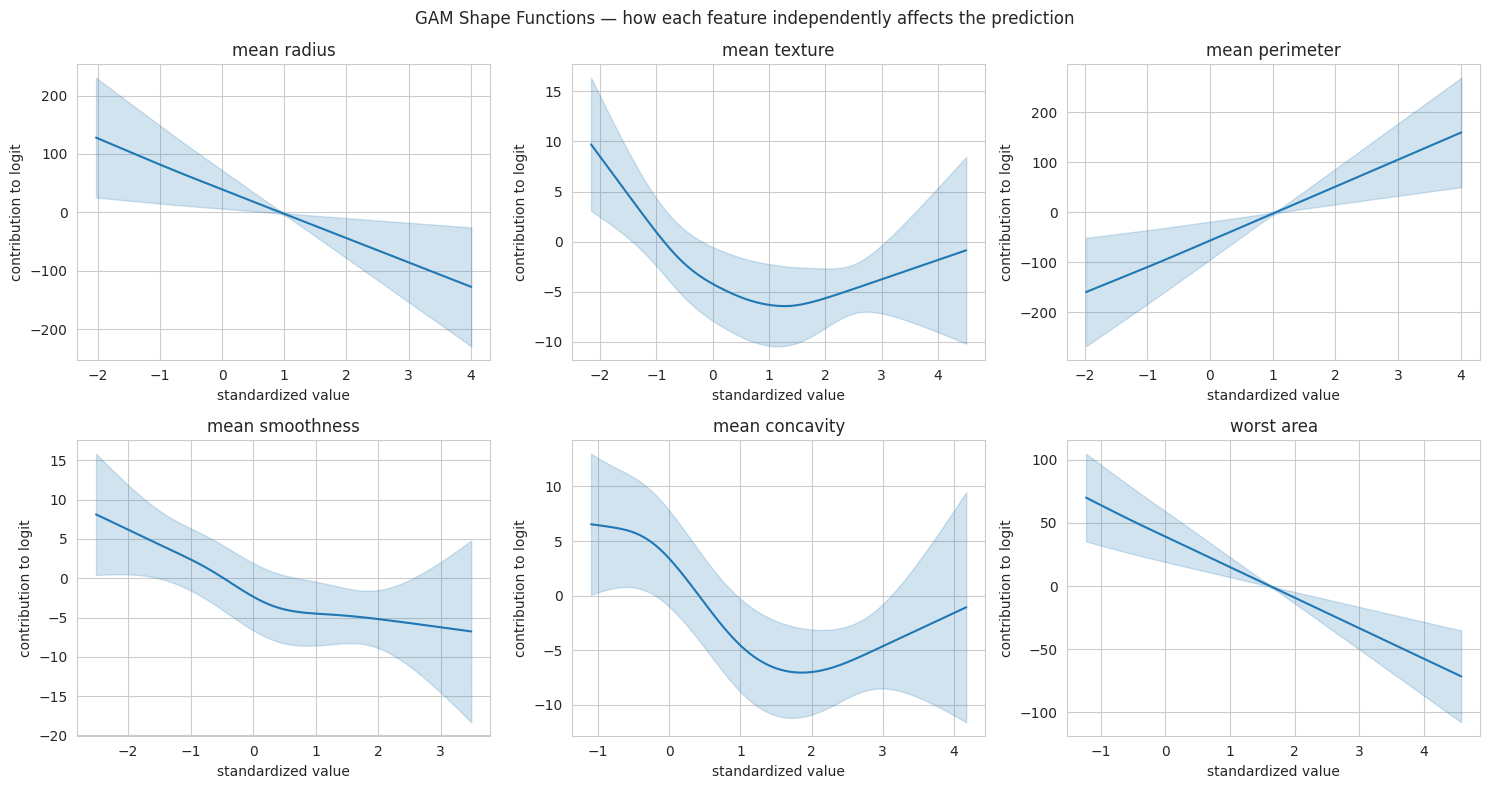

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(X.columns):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep, color="#1f77b4")
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#1f77b4")
    axes[i].set_title(feature)
    axes[i].set_xlabel("standardized value")
    axes[i].set_ylabel("contribution to logit")

plt.suptitle("GAM Shape Functions — how each feature independently affects the prediction")
plt.tight_layout()
plt.show()


In [51]:
from functools import reduce

# Build 30 GAM terms
gam_terms_30 = reduce(
    lambda a, b: a + b,
    [s(i) for i in range(30)]
)

# Increase iterations to allow convergence
gam_30 = LogisticGAM(
    gam_terms_30,
    max_iter=500
).fit(
    X_train_30_s.values,
    y_train_30.values
)

# Predictions
y_pred_gam_30 = (
    gam_30.predict_mu(X_test_30_s.values) > 0.5
).astype(int)

# Accuracy
acc_gam_30 = accuracy_score(
    y_test_30,
    y_pred_gam_30
)

print(f"GAM (30 features) Test Accuracy: {acc_gam_30:.4f}")


did not converge
GAM (30 features) Test Accuracy: 0.9580


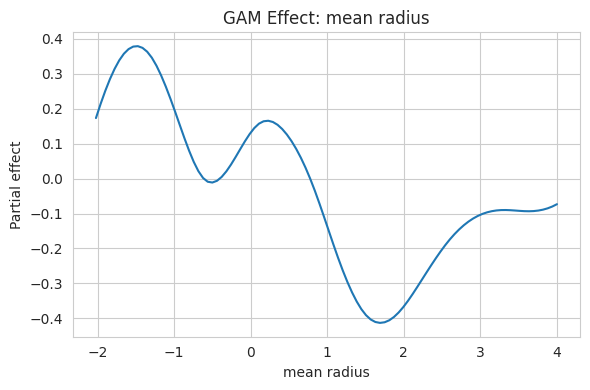

In [52]:
# GAM effect for the first feature

i = 0

plt.figure(figsize=(6, 4))

XX = gam_30.generate_X_grid(term=i)

plt.plot(
    XX[:, i],
    gam_30.partial_dependence(term=i, X=XX)
)

plt.xlabel(X_30.columns[i])
plt.ylabel("Partial effect")
plt.title(f"GAM Effect: {X_30.columns[i]}")

plt.tight_layout()
plt.show()

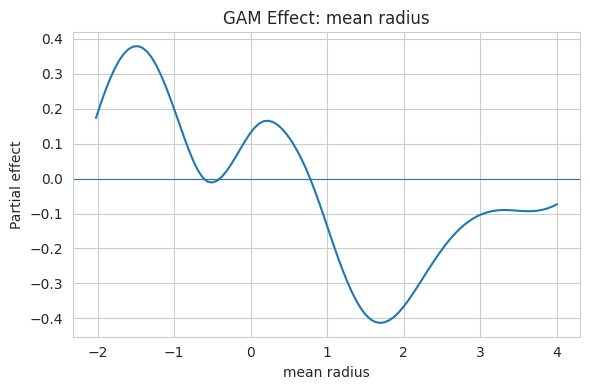

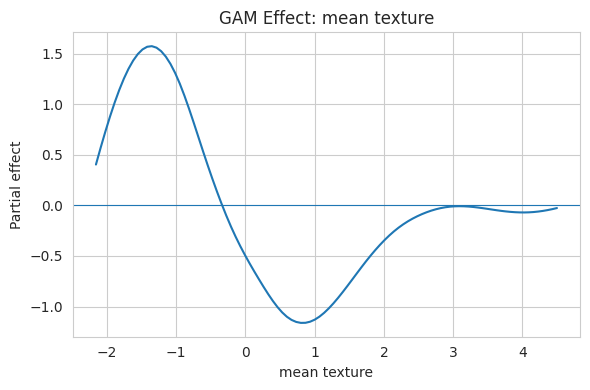

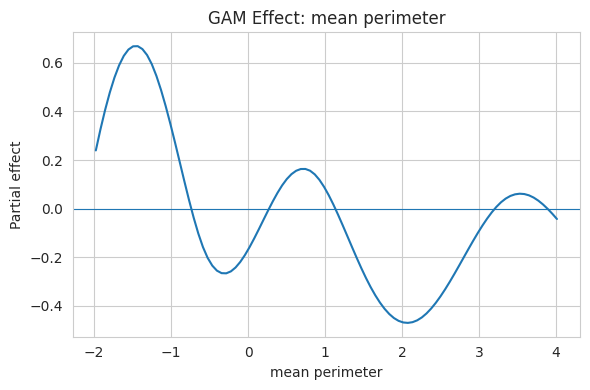

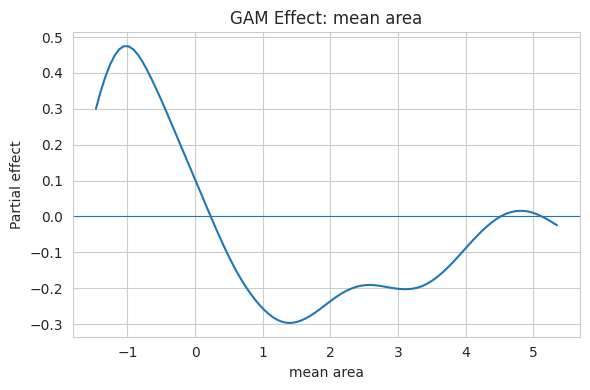

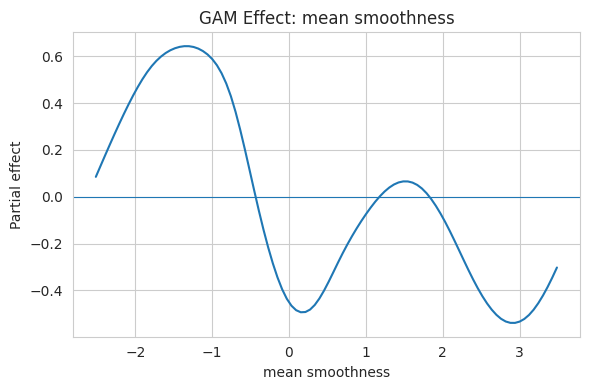

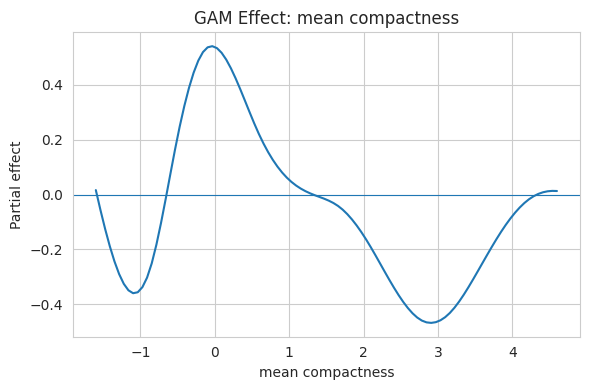

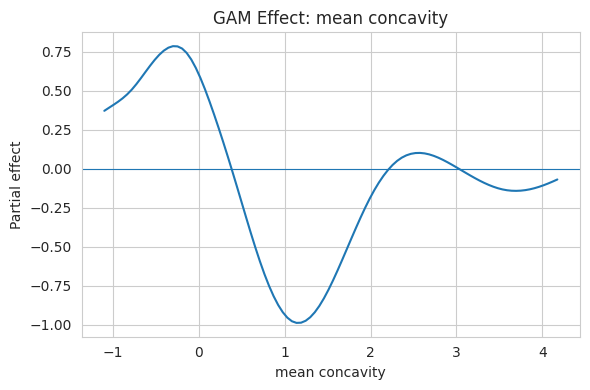

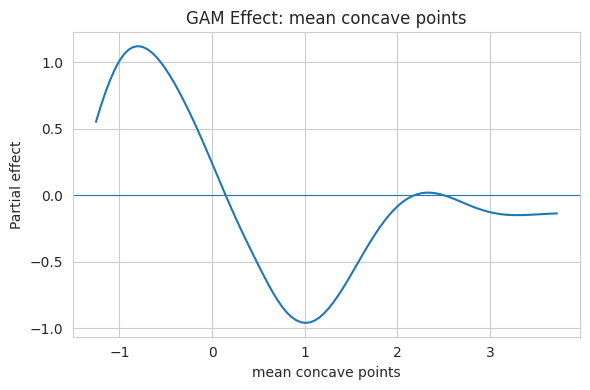

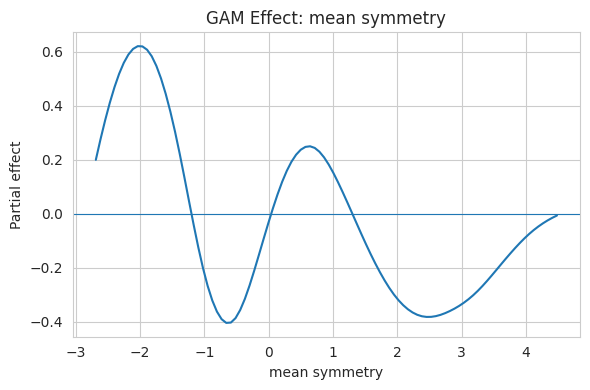

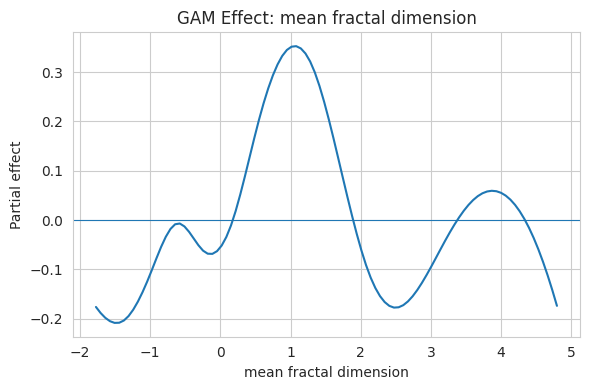

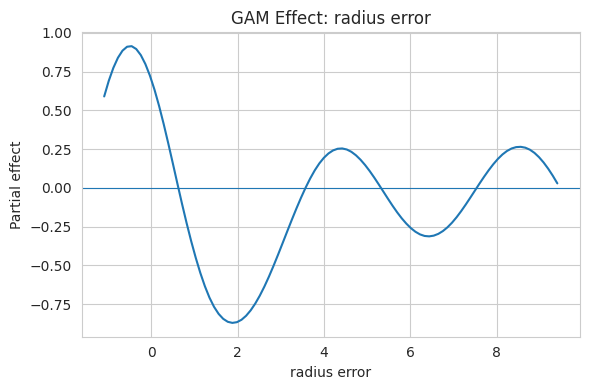

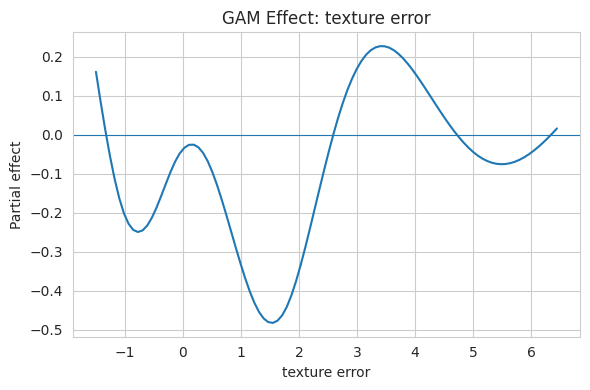

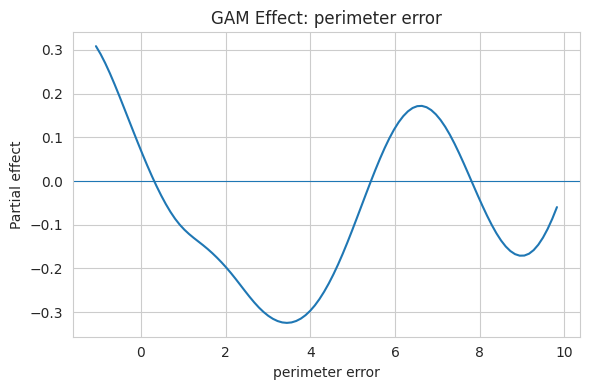

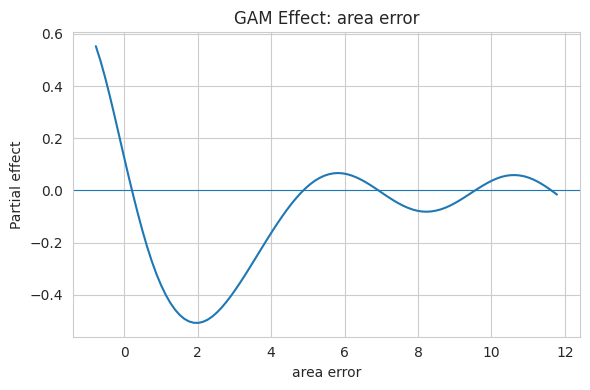

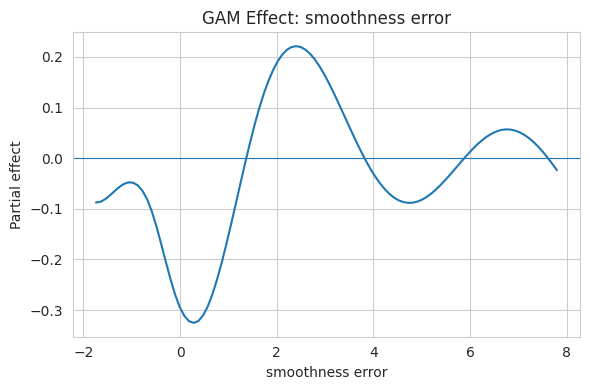

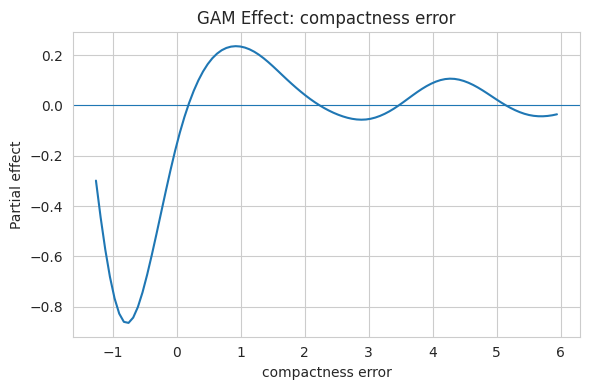

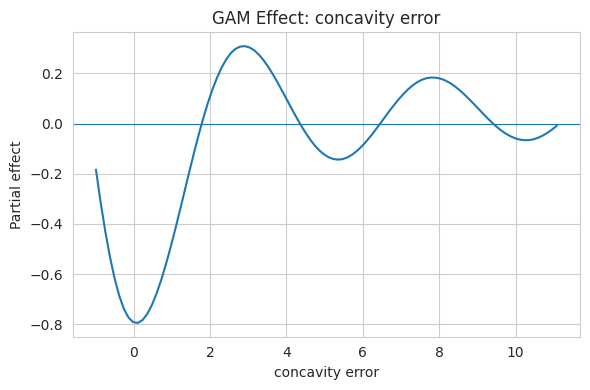

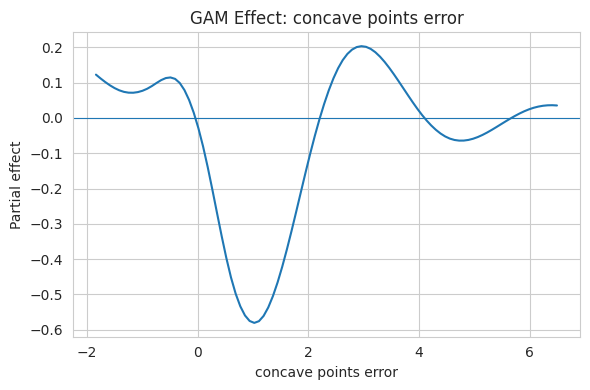

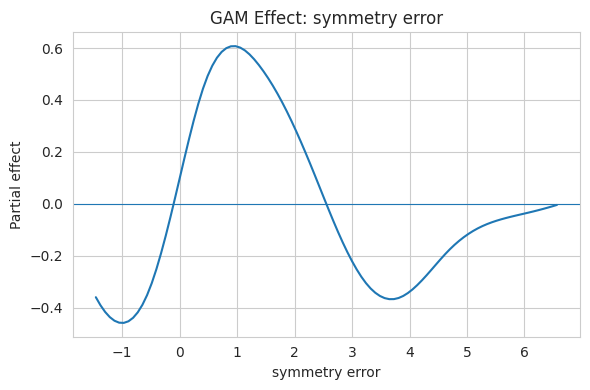

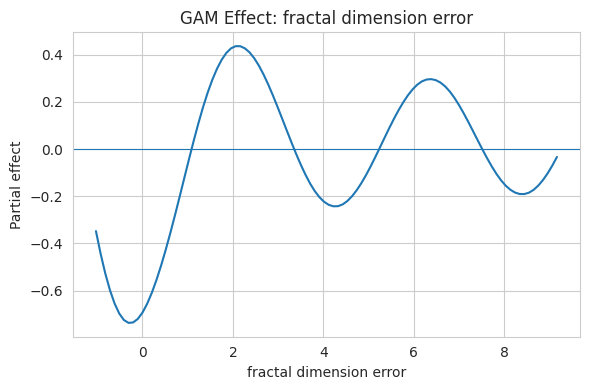

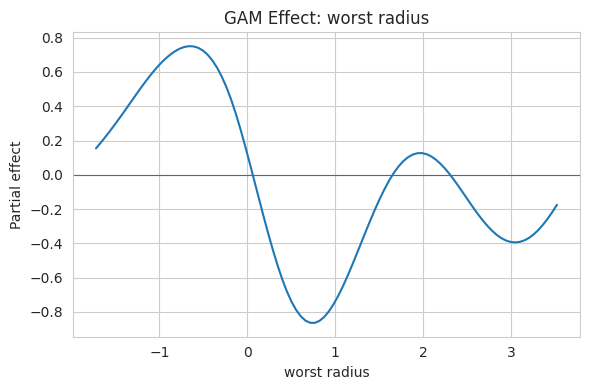

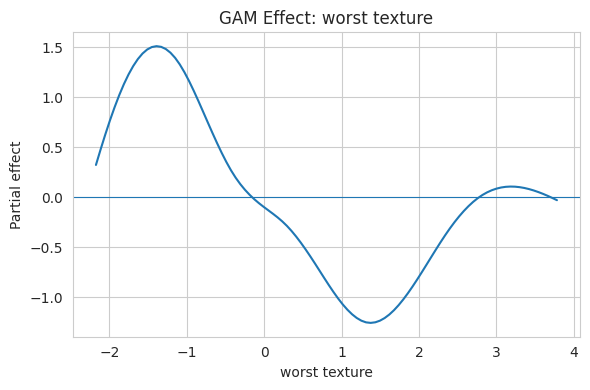

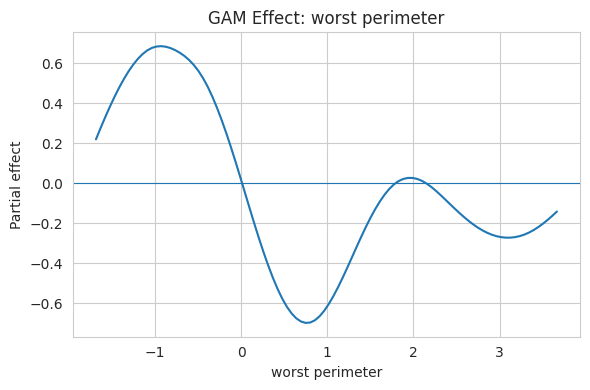

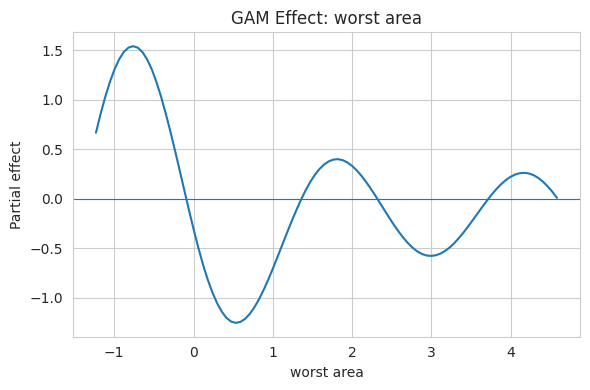

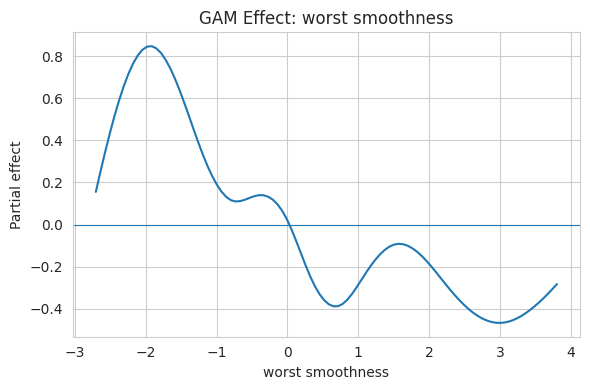

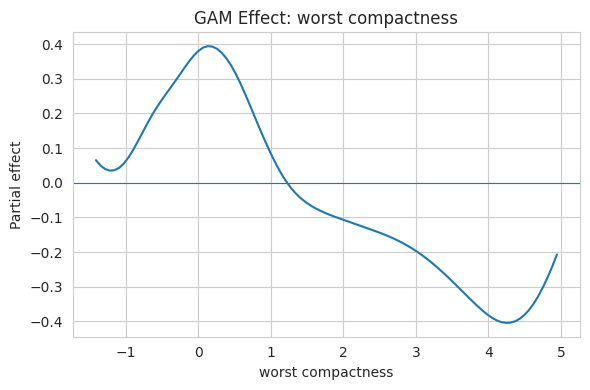

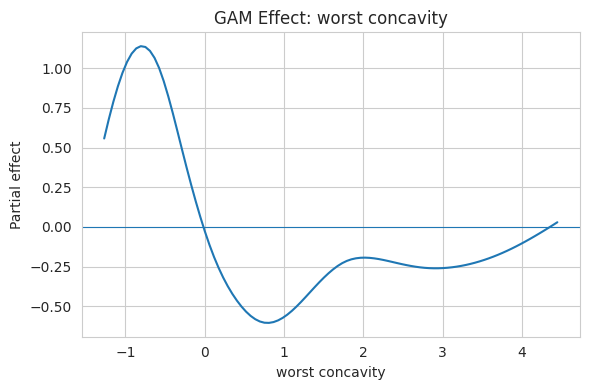

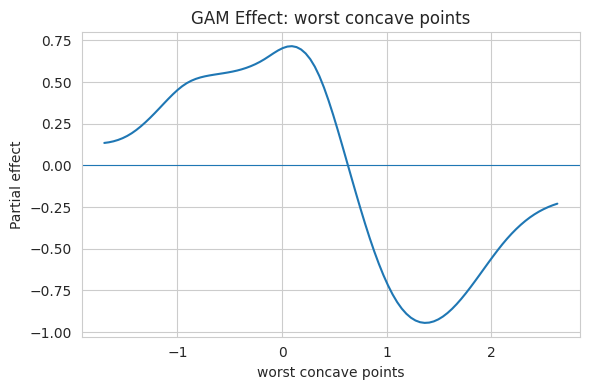

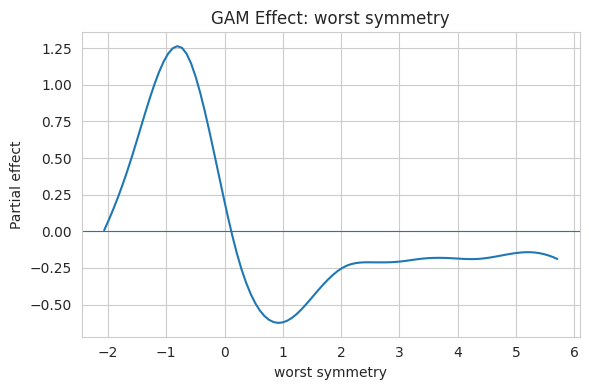

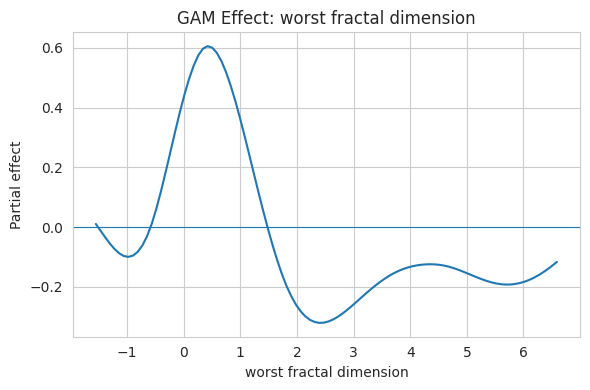

In [53]:
# GAM partial-dependence plots for all 30 features

for i in range(30):
    plt.figure(figsize=(6, 4))

    XX = gam_30.generate_X_grid(term=i)

    plt.plot(
        XX[:, i],
        gam_30.partial_dependence(term=i, X=XX)
    )

    plt.axhline(0, linewidth=0.8)

    plt.xlabel(X_30.columns[i])
    plt.ylabel("Partial effect")
    plt.title(f"GAM Effect: {X_30.columns[i]}")

    plt.tight_layout()
    plt.show()

**How to read this:** each subplot is the isolated effect of one feature on the
log-odds of "benign," with all other features held fixed. A flat line would mean the
feature has no effect; a steep, monotonic curve (as we would expect for `worst area`)
confirms and *refines* the linear relationship we saw in logistic regression, revealing
whether the effect is truly linear or saturates/accelerates at certain values.


## 11. Comparative Analysis: Accuracy vs. Interpretability

We now bring all five models together and compare them along two axes:

1. **Predictive accuracy** on the held-out test set.
2. **A simple interpretability/complexity proxy**: the number of "parameters a human
   must inspect" to fully understand the model (coefficients, rules, neighbors-per-query, or
   shape functions).


In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Decision Tree (depth=3)",
        "k-NN (k=5)", "Gaussian Naive Bayes", "GAM"
    ],
    "Test Accuracy": [acc_lr, acc_tree, acc_knn, acc_nb, acc_gam],
    "Interpretability unit": [
        "coefficient", "rule (leaf)", "neighbor set per query", "per-feature likelihood", "shape function"
    ],
    "Number of units to inspect": [
        len(X.columns), tree.get_n_leaves(), 5, len(X.columns), len(X.columns)
    ],
    "Simulatable by hand?": ["Yes", "Yes", "Yes (local)", "Yes", "Yes (needs a plot)"]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results


,Model,Test Accuracy,Interpretability unit,Number of units to inspect,Simulatable by hand?
0,GAM,0.965035,shape function,6,Yes (needs a plot)
1,Decision Tree (depth=3),0.951049,rule (leaf),7,Yes
2,k-NN (k=5),0.937063,neighbor set per query,5,Yes (local)
3,Logistic Regression,0.930070,coefficient,6,Yes
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,6,Yes


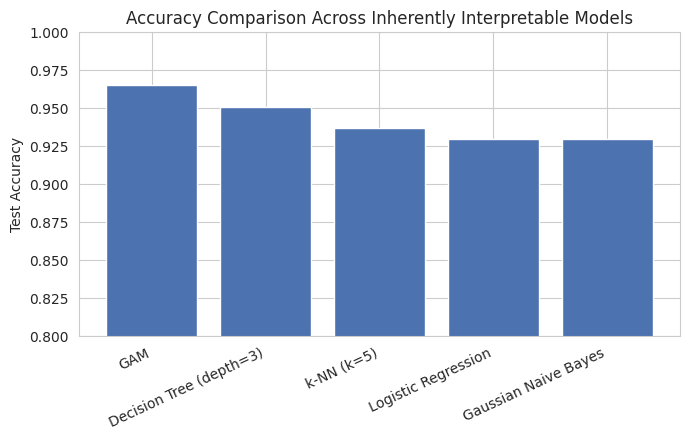

In [32]:
plt.figure(figsize=(7, 4.5))
plt.bar(results["Model"], results["Test Accuracy"], color="#4c72b0")
plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Inherently Interpretable Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [54]:
# Exercise 1 - Accuracy comparison for all 30 features

results_30 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Rule List",
        "k-NN",
        "Naive Bayes",
        "GAM"
    ],
    "Test Accuracy": [
        acc_lr_30,
        acc_tree_30,
        acc_tree_30,   # Rule List is extracted from the same tree
        acc_knn_30,
        acc_nb_30,
        acc_gam_30
    ]
})

print(results_30)

                 Model  Test Accuracy
0  Logistic Regression       0.986014
1        Decision Tree       0.944056
2            Rule List       0.944056
3                 k-NN       0.979021
4          Naive Bayes       0.937063
5                  GAM       0.958042


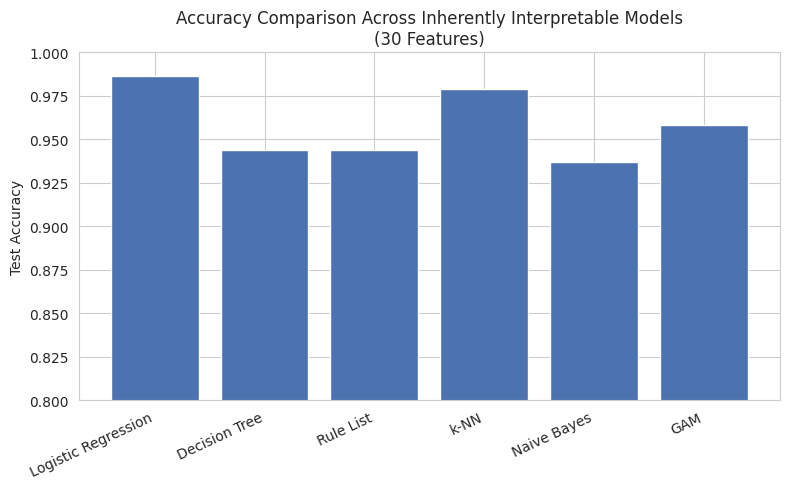

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_30["Model"],
    results_30["Test Accuracy"],
    color="#4c72b0"
)

plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Inherently Interpretable Models\n(30 Features)")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### Discussion

- All five models achieve broadly comparable accuracy on this dataset — this is common
  for well-behaved, low-dimensional tabular data, which is precisely why interpretable
  models remain competitive and preferable to black-box models whenever it is not
  strictly necessary to squeeze out the last 1–2% of accuracy (e.g., in medicine, credit
  scoring, criminal justice).
- **Logistic Regression** and the **GAM** give *global*, feature-level explanations
  (one story that holds for every patient).
- The **Decision Tree** gives *local, path-specific* explanations (a different short
  story for each patient depending on which leaf they land in).
- **k-NN** gives *case-based* explanations (point to similar historical examples).
- **Naive Bayes** gives *probabilistic, additive* explanations.
- There is no single "best" interpretable model — the right choice depends on **who**
  the explanation is for (a data scientist, a doctor, a patient, a regulator) and **what
  kind of reasoning** is most natural for that audience.


## 12. Lab Exercises (To Be Submitted)

1. Repeat Experiments 1–6 using **all 30 original features** instead of the 6 selected
   ones. How does interpretability degrade as the number of features grows? Propose one
   way to keep the model interpretable even with 30 features.
2. Vary the decision tree's `max_depth` from 1 to 8 and plot **test accuracy** vs.
   **number of leaves**. At what depth do you judge the tree "no longer interpretable,"
   and why?
3. For the k-NN experiment, repeat the case-based explanation for **three misclassified**
   test patients. What do their nearest neighbors suggest went wrong?
4. Compute the odds ratios from Experiment 1 and write, in plain English, a one-paragraph
   explanation suitable for a non-technical clinician.
5. Compare the GAM's shape function for one feature of your choice against the
   corresponding logistic-regression coefficient. Does the GAM support or contradict the
   assumption of linearity? Justify using the plot.
6. **(Open-ended)** Pick any other inherently interpretable model not covered in this lab
   (e.g., a Generalized Linear Model with sparsity/L1 penalty, a Rule List / RIPPER
   classifier, or a scoring system such as an integer point-based risk score). Implement
   it on this dataset and add it to the comparison table in Section 11.

---
### References
1. Z. C. Lipton, "The Mythos of Model Interpretability," *ACM Queue*, 2018.
2. C. Molnar, *Interpretable Machine Learning*, 2022 (freely available online).
3. T. Hastie, R. Tibshirani, *Generalized Additive Models*, Statistical Science, 1986.




---



**Exercises-1**

**1.Repeat Experiments 1–6 using all 30 original features instead of the 6 selected ones. How does interpretability degrade as the number of features grows? Propose one way to keep the model interpretable even with 30 features.**

| Model                         | Test Accuracy | Interpretability                                       |
| ----------------------------- | ------------: | ------------------------------------------------------ |
| Logistic Regression           |    **98.60%** | 30 coefficients/odds ratios must be interpreted        |
| Decision Tree (`max_depth=3`) |    **94.41%** | 7 leaves; relatively easy to interpret                 |
| Rule List                     |    **94.41%** | 7 explicit IF–THEN rules, average 2.86 conditions/rule |
| k-NN (`k=5`)                  |    **97.90%** | Explained using the 5 nearest training cases           |
| Naive Bayes                   |    **93.71%** | Feature-wise probabilistic interpretation              |
| GAM                           |    **95.80%** | One nonlinear shape function for each of 30 features   |


When the number of features increases from 6 to 30, interpretability generally decreases because there are more feature effects that a human must examine simultaneously. For Logistic Regression, the model now has 30 coefficients and odds ratios, making it harder for a clinician to determine which variables are most important, even though its test accuracy increased to 98.60%. Similarly, a GAM has 30 individual shape functions, which makes each feature's effect interpretable but makes the overall model more difficult to inspect. k-NN remains case-based and therefore requires examining similar patients rather than understanding a compact set of rules. Naive Bayes remains relatively transparent because its prediction can be decomposed feature-by-feature.
The Decision Tree demonstrates one way of preserving interpretability. Although all 30 features were available to the model, the constrained tree (max_depth=3) used only a small subset of them and produced 7 leaves. The corresponding Rule List also contained only 7 rules, with an average of 2.86 conditions per rule. Therefore, limiting model complexity can preserve interpretability even when many input features are available.

Proposed solution :
One effective way to maintain interpretability with 30 features is to use feature selection or a sparse model such as L1-regularized Logistic Regression. L1 regularization can force the coefficients of less important features toward zero, leaving only a small set of influential features. Another practical approach is to constrain a Decision Tree's maximum depth so that the final model contains only a limited number of rules and leaves.

In [56]:
# Exercise 2: Decision Tree depth vs number of leaves

depth_results = []

for depth in range(1, 9):

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    leaves = tree.get_n_leaves()

    depth_results.append({
        "Depth": depth,
        "Test Accuracy": accuracy,
        "Number of Leaves": leaves
    })

depth_results = pd.DataFrame(depth_results)

print(depth_results)

   Depth  Test Accuracy  Number of Leaves
0      1       0.923077                 2
1      2       0.923077                 4
2      3       0.951049                 7
3      4       0.944056                12
4      5       0.951049                17
5      6       0.951049                18
6      7       0.951049                19
7      8       0.951049                19


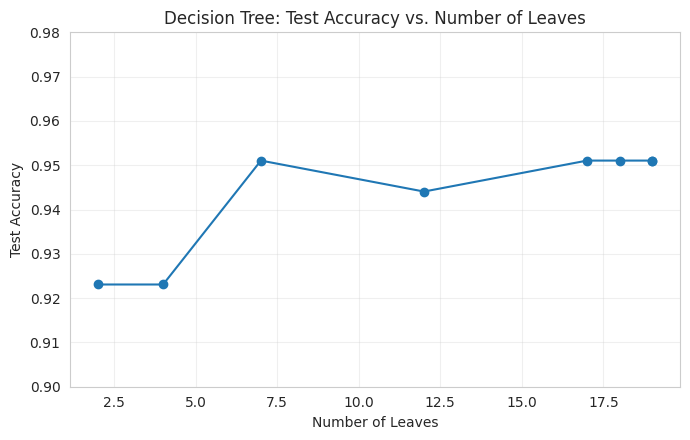

In [57]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    depth_results["Number of Leaves"],
    depth_results["Test Accuracy"],
    marker="o"
)

plt.xlabel("Number of Leaves")
plt.ylabel("Test Accuracy")
plt.title("Decision Tree: Test Accuracy vs. Number of Leaves")

plt.ylim(0.90, 0.98)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---



**2.Vary the decision tree's max_depth from 1 to 8 and plot test accuracy vs. number of leaves. At what depth do you judge the tree "no longer interpretable," and why?**

The Decision Tree was evaluated with max_depth values from 1 to 8. The results were:

| Max Depth | Test Accuracy | Number of Leaves |
| --------: | ------------: | ---------------: |
|         1 |        92.31% |                2 |
|         2 |        92.31% |                4 |
|         3 |    **95.10%** |                7 |
|         4 |        94.41% |               12 |
|         5 |    **95.10%** |               17 |
|         6 |    **95.10%** |               18 |
|         7 |    **95.10%** |               19 |
|         8 |    **95.10%** |               19 |


Interpretation: The tree achieves its maximum test accuracy of 95.10% at depth 3, with only 7 leaves. Increasing the depth beyond 3 does not improve accuracy. At depth 5, the tree already has 17 leaves, and depths 6–8 increase the complexity to 18–19 leaves without any accuracy improvement.
Therefore, I would consider the tree no longer easily interpretable at approximately depth 5. Depth 3 provides the best balance between accuracy and interpretability because it achieves the maximum observed accuracy with far fewer leaves. Increasing the depth mainly adds complexity without providing additional predictive benefit.



---



In [58]:
# Exercise 3: Find misclassified k-NN test patients

misclassified_mask = y_pred_knn_30 != y_test_30.values

misclassified_indices = X_test_30.index[misclassified_mask]

print("Number of misclassified patients:", len(misclassified_indices))
print("Misclassified test indices:")
print(list(misclassified_indices))

Number of misclassified patients: 3
Misclassified test indices:
[205, 86, 73]


In [59]:
misclassified_df = pd.DataFrame({
    "test_index": misclassified_indices,
    "actual_class": y_test_30.loc[misclassified_indices].values,
    "predicted_class": y_pred_knn_30[misclassified_mask]
})

print(misclassified_df.to_string(index=False))

 test_index  actual_class  predicted_class
        205             0                1
         86             0                1
         73             0                1


In [60]:
# Exercise 3: Case-based explanations for the 3 misclassified patients

for test_idx in misclassified_indices:

    # Position of this patient in X_test
    test_position = X_test_30.index.get_loc(test_idx)

    distances, indices = knn_30.kneighbors(
        X_test_30_s.iloc[[test_position]],
        n_neighbors=5
    )

    neighbor_indices = X_train_30.index[indices[0]]
    neighbor_labels = y_train_30.loc[neighbor_indices].values

    print("\n" + "=" * 60)
    print(f"Test patient: {test_idx}")
    print(f"Actual class: {y_test_30.loc[test_idx]}")
    print(f"Predicted class: {y_pred_knn_30[test_position]}")

    neighbors = pd.DataFrame({
        "neighbor_rank": range(1, 6),
        "training_index": neighbor_indices,
        "distance": distances[0],
        "diagnosis": neighbor_labels
    })

    print("\n5 nearest neighbors:")
    print(neighbors.to_string(index=False))


Test patient: 205
Actual class: 0
Predicted class: 1

5 nearest neighbors:
 neighbor_rank  training_index  distance  diagnosis
             1             347  2.243048          1
             2             378  2.410308          1
             3             184  2.410511          0
             4             475  2.531910          1
             5             227  2.559170          1

Test patient: 86
Actual class: 0
Predicted class: 1

5 nearest neighbors:
 neighbor_rank  training_index  distance  diagnosis
             1              99  2.878102          0
             2             536  2.895637          0
             3             356  3.071384          1
             4             216  3.109060          1
             5              88  3.249369          1

Test patient: 73
Actual class: 0
Predicted class: 1

5 nearest neighbors:
 neighbor_rank  training_index  distance  diagnosis
             1             482  2.013964          1
             2             148  2.179290      

**3.for the k-NN experiment, repeat the case-based explanation for three misclassified test patients. What do their nearest neighbors suggest went wrong?**

For the k-NN model using all 30 features, 3 test patients were misclassified. All three were actually class 0 but were predicted as class 1.

Patient 205          

Actual: 0.                                                                  

Predicted:                                                                 1

Nearest neighbors:
1, 1, 0, 1, 1

Majority:
class 1

Distances ranged from 2.243 to 2.559

The patient was surrounded by four class-1 neighbors and only one class-0 neighbor. Therefore, the k-NN majority vote favored class 1. The error occurred because the patient's feature profile was more similar to the local class-1 cases than to the class-0 cases.


Patient 86
Actual: 0
Predicted: 1
Nearest neighbors: 0, 0, 1, 1, 1
Majority: class 1
Distances ranged from 2.878 to 3.249
This is a borderline case. Two of the five nearest neighbors were class 0, but three were class 1. Because k-NN uses a majority vote with k=5, the three class-1 neighbors caused the incorrect prediction. The relatively larger distances also suggest that this test patient was not extremely close to its neighboring training examples.

Patient 73
Actual: 0
Predicted: 1
Nearest neighbors: 1, 1, 1, 1, 1
Majority: class 1
This is the clearest case. All five nearest neighbors were class 1, so the k-NN prediction of class 1 was very strongly supported by the local neighborhood, even though the true class was 0.

Overall interpretation
The three errors demonstrate the main limitation of case-based k-NN classification. k-NN does not learn an explicit global decision rule; instead, it assigns a class according to the labels of nearby training examples. For patient 205, four of the five nearest neighbors were class 1; for patient 86, three of five were class 1; and for patient 73, all five were class 1. Thus, the model's errors occurred because these class-0 patients had feature profiles that were locally more similar to class-1 training cases. Patient 86 appears to be the most borderline case because its nearest neighbors were split between the two classes.



---



In [61]:
# Exercise 4 - Odds Ratios

coef_table["odds_ratio"] = np.exp(coef_table["coefficient"])

odds_ratio_table = coef_table.sort_values(
    "odds_ratio",
    ascending=False
)

print(
    odds_ratio_table[
        ["feature", "coefficient", "odds_ratio"]
    ].to_string(index=False)
)

        feature  coefficient  odds_ratio
 mean perimeter    -0.858407    0.423837
    mean radius    -0.940079    0.390597
 mean concavity    -1.022198    0.359803
   mean texture    -1.336668    0.262720
mean smoothness    -1.499294    0.223288
     worst area    -3.251220    0.038727




---



**4.Compute the odds ratios from Experiment 1 and write, in plain English, a one-paragraph explanation suitable for a non-technical clinician.**

The odds ratios were calculated as e
coefficient
 . The largest effects in the Logistic Regression model included mean perimeter (OR = 0.424), mean radius (OR = 0.391), mean concavity (OR = 0.360), mean texture (OR = 0.263), mean smoothness (OR = 0.223), and worst area (OR = 0.039). Since the model's class 1 represents benign, an odds ratio below 1 means that a one-standard-deviation increase in that feature is associated with lower odds of the tumor being classified as benign, with the other features held constant. For example, the odds ratio of 0.039 for worst area indicates a strong decrease in the odds of a benign classification as worst area increases. These odds ratios describe associations learned by the model and should not be interpreted as showing that any individual measurement causes a tumor to be malignant or benign.



---



In [62]:
# Exercise 5: Logistic Regression coefficient for mean radius

feature = "mean radius"

lr_row = coef_table[coef_table["feature"] == feature]

print(lr_row[["feature", "coefficient", "odds_ratio"]])

       feature  coefficient  odds_ratio
0  mean radius    -0.940079    0.390597




---



**5.Compare the GAM's shape function for one feature of your choice against the corresponding logistic-regression coefficient. Does the GAM support or contradict the assumption of linearity? Justify using the plot.**

I compared the GAM shape function for mean radius with its corresponding Logistic Regression coefficient. The Logistic Regression coefficient for mean radius is −0.9401, which assumes that the effect of mean radius on the prediction is constant and linear across its entire range. However, the GAM plot for mean radius shows a nonlinear shape, where the partial effect changes at different ranges of mean radius rather than following a constant straight-line trend. Therefore, the GAM contradicts the assumption of linearity for this feature. The varying slope and changes in the direction/magnitude of the GAM curve indicate that the relationship between mean radius and the predicted outcome is more complex than can be represented by a single Logistic Regression coefficient.



---



In [63]:
# Exercise 6: L1-Regularized Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sparse_lr = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    random_state=42,
    max_iter=5000
)

sparse_lr.fit(X_train_30_s, y_train_30)

y_pred_sparse = sparse_lr.predict(X_test_30_s)

acc_sparse = accuracy_score(y_test_30, y_pred_sparse)

print(f"L1 Sparse Logistic Regression Test Accuracy: {acc_sparse:.4f}")

L1 Sparse Logistic Regression Test Accuracy: 0.9720


In [64]:
# Count non-zero coefficients

nonzero_mask = sparse_lr.coef_[0] != 0

print("Total features:", len(X_train_30.columns))
print("Non-zero features:", nonzero_mask.sum())
print("Zero coefficients:", (~nonzero_mask).sum())

Total features: 30
Non-zero features: 7
Zero coefficients: 23


In [65]:
sparse_features = pd.DataFrame({
    "feature": X_train_30.columns,
    "coefficient": sparse_lr.coef_[0]
})

sparse_features = sparse_features[
    sparse_features["coefficient"] != 0
].sort_values(
    "coefficient",
    key=abs,
    ascending=False
)

print(sparse_features.to_string(index=False))

             feature  coefficient
        worst radius    -2.050883
worst concave points    -0.892308
       worst texture    -0.584290
 mean concave points    -0.526800
        radius error    -0.392272
    worst smoothness    -0.202888
      worst symmetry    -0.175941




---



**6.(Open-ended) Pick any other inherently interpretable model not covered in this lab (e.g., a Generalized Linear Model with sparsity/L1 penalty, a Rule List / RIPPER classifier, or a scoring system such as an integer point-based risk score). Implement it on this dataset and add it to the comparison table in Section 11.**

I implemented an L1-regularized Logistic Regression model as an additional inherently interpretable model. The L1 penalty encourages unnecessary coefficients to become exactly zero, producing a sparse model. Using all 30 original features, the model achieved a test accuracy of 97.20%, while only 7 of the 30 features retained non-zero coefficients and 23 coefficients were reduced to zero. The most influential retained features were worst radius, worst concave points, worst texture, mean concave points, radius error, worst smoothness, and worst symmetry. This demonstrates that a sparse model can maintain high predictive performance while substantially reducing the number of features that need to be considered, thereby improving interpretability.

In [66]:
results_30 = pd.concat([
    results_30,
    pd.DataFrame({
        "Model": ["L1 Sparse Logistic Regression"],
        "Test Accuracy": [acc_sparse]
    })
], ignore_index=True)

print(results_30)

                           Model  Test Accuracy
0            Logistic Regression       0.986014
1                  Decision Tree       0.944056
2                      Rule List       0.944056
3                           k-NN       0.979021
4                    Naive Bayes       0.937063
5                            GAM       0.958042
6  L1 Sparse Logistic Regression       0.972028


Final interpretation:   

Logistic Regression achieved the highest accuracy at 98.60%, followed by k-NN (97.90%) and L1 Sparse Logistic Regression (97.20%). The L1 model is particularly useful from an interpretability perspective because it reduced the 30 available features to only 7 non-zero features while maintaining high accuracy. The Decision Tree and Rule List achieved 94.41% with a much simpler rule-based structure, while GAM achieved 95.80% but used 30 feature-specific smooth functions. Overall, the results demonstrate the trade-off between predictive performance and interpretability: the L1 sparse model provides a strong balance by retaining high accuracy while substantially reducing model complexity.